In [16]:
! pip install folium

In [17]:
from astrovision.plot.plot_utils import make_mosaic
from astrovision.data import SatelliteImage, SegmentationLabeledSatelliteImage
import s3fs
import os
import geopandas as gpd
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import folium

### Import

In [18]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})
out  = fs.download(rpath="projet-slums-detection/ilots", lpath="ilots", recursive=True)
out = fs.download(rpath="projet-slums-detection/data-prediction/PLEIADES/MAYOTTE", lpath="pred_mayotte", recursive=True)


In [19]:
pred_2020 = gpd.read_file('pred_mayotte/2020/predictions.gpkg')
pred_2023 = gpd.read_file('pred_mayotte/2023/predictions.gpkg')
#print(pred_2020.head())
ilots = gpd.read_file("ilots/ilots.gpkg")

#tgt_crs = CRS.from_epsg(4326)
tgt_crs = CRS.from_epsg(4471) # mayotte 

# codes départements : 
#   - 971 Guadeloupe
#   - 972 Martinique
#   - 973 Guyane
#   - 974 Réunion
#   - 976 Mayotte

pred_2020 = pred_2020.to_crs(tgt_crs)
pred_2023 = pred_2023.to_crs(tgt_crs)
#pred_2020.geometry.iloc[2]

ilots = ilots.to_crs(tgt_crs)

KeyboardInterrupt: 

### Visualisation

In [ ]:
center = list(pred_2020.iloc[0]['geometry'].centroid.coords)[0]
# initialisation de la carte
m = folium.Map(location=center, zoom_start=10)
# Add a GeoJSON layer from the GeoDataFrame to the map
folium.GeoJson(pred_2020).add_to(m)

ilots = ilots.to_crs(tgt_crs)

### Ajout de l'aire

In [ ]:
pred_2020["area"] = pred_2020.area
pred_2023["area"] = pred_2023.area
ilotsMayotte["area"] = ilotsMayotte.geometry.area
# pred_2020["area"]
# pred_2023["area"]

### Visualisation Mayotte

<Axes: >

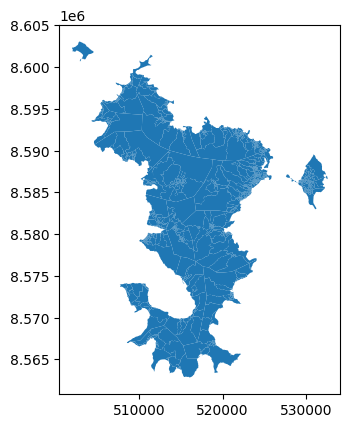

In [ ]:
ilotsMayotte = ilots[ilots["ident_ilot"].str.startswith('976')]
ilotsMayotte.plot()

## Fonctions

In [20]:
def valeurs_extremes(tableau, n, colonne, mode='top'):
    """
    Objectif de la fonction : Sélectionner et renvoyer les n lignes du tableau avec les valeurs les plus hautes ou les plus basses de la colonne spécifiée.
    
    Paramètres :
    - tableau (list): Le tableau de données à traiter. Chaque élément du tableau est supposé être un dictionnaire représentant une ligne de données.
    - n (int): Le nombre de lignes à sélectionner.
    - colonne (str): Le nom de la colonne selon laquelle les valeurs seront comparées.
    - mode (str, optionnel): Le mode de sélection, 'top' pour les valeurs les plus hautes, 'bottom' pour les valeurs les plus basses. Par défaut, 'top'.
    
    Sortie :
    list: Le tableau contenant les n lignes sélectionnées.
    """

    gdf_sorted = tableau.sort_values(by=colonne, ascending=(mode != 'top'))

    lignes = gdf_sorted.head(n)

    return lignes

In [21]:
print(valeurs_extremes(ilotsMayotte, 5, 'area', 'top'))

      ident_ilot  code depcom_2018  ident_up  \
20008  976170312  0312       97617  UP000000   
19857  976130106  0106       97613  UP000000   
19256  976010103  0103       97601  UP000000   
19801  976110705  0705       97611  UP000000   
19298  976020402  0402       97602  UP000000   

                                                geometry          area  
20008  MULTIPOLYGON (((518725.999 8587993.000, 517691...  1.147266e+07  
19857  MULTIPOLYGON (((509528.376 8590081.452, 509510...  1.081639e+07  
19256  MULTIPOLYGON (((508861.001 8592290.395, 507064...  7.734441e+06  
19801  MULTIPOLYGON (((519473.996 8582824.402, 516800...  7.404527e+06  
19298  MULTIPOLYGON (((512572.093 8591327.555, 512566...  7.250946e+06  


### Visualisation de l'emploi de la fonction

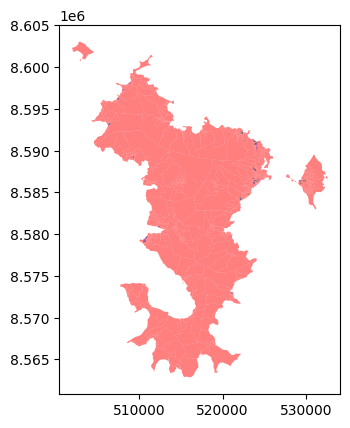

In [22]:
top_2020 = valeurs_extremes(pred_2020, 20, 'area', 'top')
top_2023 = valeurs_extremes(pred_2023, 20, 'area', 'top')

# Create a figure and axes object
fig, ax = plt.subplots()

# Plot the first GeoDataFrame in red
ilotsMayotte.plot(ax=ax, color='red', alpha=0.5)

# Plot the second GeoDataFrame in green
top_2020.plot(ax=ax, color='green', alpha=0.5)

# Plot the third GeoDataFrame in blue
top_2023.plot(ax=ax, color='blue', alpha=0.5)

# Show the plot
plt.show()

## Découpage des bâtiments pour qu'ils n'appartiennent qu'à un seul îlot

Ce découpage semblait être une bonne idée au début, pour avoir des polygones sur un seul îlot
mais l'intersection est en fait assez simple, donc peut-être pas pertinent
mais ça m'a aidé à comprendre geopandas un peu.

Le but est donc de découper les polygones, sauf qu'il y a peut-être des erreurs. On le vérifiera après.

In [ ]:


# # Assurez-vous que vous avez défini vos GeoDataFrames ilots et pred_2020 correctement avant d'exécuter ce code

# # Créez nouvelle_table avec la bonne colonne de géométrie
# nouvelle_table = gpd.GeoDataFrame()

# # Corriger les géométries invalides dans ilots
# ilots['geometry'] = ilots['geometry'].buffer(0)

# # Corriger les géométries invalides dans pred_2020
# pred_2020['geometry'] = pred_2020['geometry'].buffer(0)

# # Vérifiez le type des colonnes de géométrie
# print(type(ilots['geometry']))
# print(type(pred_2020['geometry']))

# # Parcourir chaque îlot
# for i in range(len(ilots)):
#     ilot = ilots.iloc[i]
    
#     # Sélectionner les polygones de pred_2020 qui intersectent cet îlot
#     polygones_intersectes = pred_2020[pred_2020.intersects(ilot.geometry)]
    
#     # Si aucun polygone n'intersecte, passer à l'îlot suivant
#     if polygones_intersectes.empty:
#         continue
    
#     # Effectuer l'intersection entre les polygones de pred_2020 et l'îlot
#     polygones_decoupes = polygones_intersectes.intersection(ilot.geometry)
    
#     # Ajouter les polygones découpés à la nouvelle table
#     nouvelle_table = gpd.GeoDataFrame(pd.concat([nouvelle_table, polygones_decoupes], ignore_index=True))
    
# print(nouvelle_table)
# print(pred_2020.geometry)

# nouvelle_table = nouvelle_table.set_geometry(nouvelle_table[0])

# print(pred_2020.crs)
# print(ilots.crs)
# bat_decoupes = nouvelle_table
# print(bat_decoupes.crs)




In [ ]:
# pred_2020
# ilotsMayotte
# ilot_test_geom
# pred_2020.intersects(ilot_test_geom)
# ilot_test_geom.crs
# pred_2020.intersects(ilot_test_geom)
# pred_2020
# ilot_test_geom.plot()

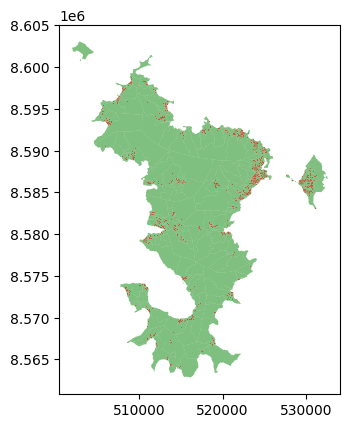

In [26]:
intersection = gpd.overlay(pred_2020, ilotsMayotte, how='intersection')

# Create a figure and axes object
fig, ax = plt.subplots()

# Plot the second GeoDataFrame in green
ilotsMayotte.plot(ax=ax, color='green', alpha=0.5)

# Plot the first GeoDataFrame in red
intersection.plot(ax=ax, color='red', alpha=0.5)

# Show the plot
plt.show()

       ident_pred  count
142           147      2
146           151      2
156           161      2
193           198      2
225           230      2
...           ...    ...
26660       26750      2
26663       26753      2
26665       26755      2
26667       26757      2
26701       26791      3

[1207 rows x 2 columns]
                                                filename   id  area_1  \
28137  projet-slums-detection/data-raw/PLEIADES/MAYOT...  572  437.25   
28138  projet-slums-detection/data-raw/PLEIADES/MAYOT...  572  437.25   

       ident_pred ident_ilot  code depcom_2018  ident_up        area_2  \
28137       26757  976150104  0104       97615  UP000000  49357.634158   
28138       26757  976150108  0108       97615  UP000000  26439.963192   

                                                geometry  
28137  POLYGON ((530730.500 8586101.500, 530730.500 8...  
28138  MULTIPOLYGON (((530726.616 8586101.500, 530725...  


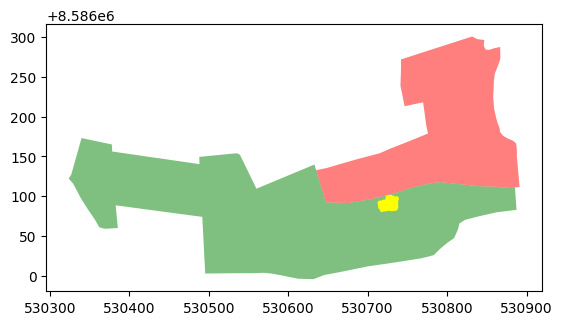

In [27]:
pred_2020 = pred_2020.assign(ident_pred=pd.Series(range(1, len(intersection)+1), index=intersection.index))
intersection = gpd.overlay(pred_2020, ilotsMayotte, how='intersection')

counts = intersection.groupby(['ident_pred']).size().reset_index(name='count')
print(counts.loc[counts["count"] > 1])

ident_pred = 26757
code_ilot1 = "976150104"
code_ilot2 = "976150108"

ilots1 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code_ilot1]
ilots2 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code_ilot2]

inters  = intersection.loc[intersection["ident_pred"]==ident_pred]
print(inters)

# Create a figure and axes object
fig, ax = plt.subplots()

# Plot the second GeoDataFrame in green
ilots1.plot(ax=ax, color='green', alpha=0.5)

# Plot the first GeoDataFrame in red
ilots2.plot(ax=ax, color='red', alpha=0.5)

inters.plot(ax=ax, color='yellow', alpha=1)

# Show the plot
plt.show()



In [ ]:
ilots1_folium = ilots1.to_crs(4326)
ilots2_folium = ilots2.to_crs(4326)
inters_folium = inters.to_crs(4326)

center = list(ilots1_folium.iloc[0]['geometry'].centroid.coords)[0]
center =  (center[1],center[0])
m = folium.Map(location=center, zoom_start=10)
folium.GeoJson(ilots1).add_to(m)
folium.GeoJson(ilots2).add_to(m)

def style_function(feature):
    return {'fillColor': 'yellow', 'color': 'black', 'weight': 3, 'fillOpacity': 0.5}

def style_function2(feature):
    return {'fillColor': 'red', 'color': 'black', 'weight': 3, 'fillOpacity': 0.5}

folium.GeoJson(inters_folium.iloc[0].geometry, style_function= style_function).add_to(m)
folium.GeoJson(inters_folium.iloc[1].geometry, style_function=style_function2).add_to(m)

m

### Conclusion :
D'une part, les îlots sont construits de façon à passer entre les bâtiments. On peut donc considérer que les bâtiments présents sur deux îlots sont peu nombreux et que leur aire est négligeable. 
D'autre part, la fonction intersect ne prend que la zone du polygone qui est présente dans l'îlot, et non l'îlot entier présent dans l'intersection. Donc c'est parfait, pas besoin de découper les polygones pour faire les analyses suivantes. 

## Aires par îlot

On va aussi vérifier si c'est les bons résultats pour le découpage d'avant

In [31]:
# # Parcourir chaque îlot
# for i in range(len(ilotsMayotte)):
#     ilot = ilotsMayotte.iloc[i]
    
#     # Sélectionner les polygones de pred_2020 qui intersectent cet îlot
#     polygones_intersectes = pred_2020[pred_2020.intersects(ilot.geometry)]
    
#     # Si aucun polygone n'intersecte, passer à l'îlot suivant
#     if polygones_intersectes.empty:
#         continue
    
#     # Effectuer l'intersection entre les polygones de pred_2020 et l'îlot
#     polygones_decoupes = polygones_intersectes.intersection(ilot.geometry)
    
#     # Ajouter les polygones découpés à la nouvelle table
#     nouvelle_table = gpd.GeoDataFrame(pd.concat([nouvelle_table, polygones_decoupes], ignore_index=True))
    
#     # Calculer l'aire construite pour cet îlot
#     aire_construite = polygones_decoupes.area.sum()
    
#     # Ajouter l'aire construite à la table des îlots
#     ilotsaire = ilots
#     ilotsaire.loc[i, 'aire_construite2020'] = aire_construite

# #ilotsaire = ilotsaire.dropna(subset=['aire_construite2020'])

# #print(ilotsaire.aire_construite2020)

# print(valeurs_extremes(ilotsaire, 15, 'aire_construite2020', 'top'))


NameError: name 'nouvelle_table' is not defined

In [94]:
pred_2023 = pred_2023.assign(ident_pred=pd.Series(range(1, len(intersection)+1), index=intersection.index))
inters20 = gpd.overlay(pred_2020, ilotsMayotte, how='intersection')
inters23 = gpd.overlay(pred_2023, ilotsMayotte, how='intersection')


In [95]:
aireParIlot20 = inters20.groupby('ident_ilot')['area_1'].sum()
aireParIlot23 = inters23.groupby('ident_ilot')['area_1'].sum()

In [96]:
aireParIlot23

ident_ilot
976010101    34048.25
976010102    23222.00
976010103    29574.25
976010104    27848.75
976010105    26441.50
               ...   
976170406    11353.25
976170407    10230.50
976170408    15076.50
976170409    11943.75
976170410     5108.00
Name: area_1, Length: 810, dtype: float64

In [97]:
diff_index = aireParIlot20.index.symmetric_difference(aireParIlot23.index)
print(diff_index)

Différence d'indexation :
Index(['976100114'], dtype='object', name='ident_ilot')


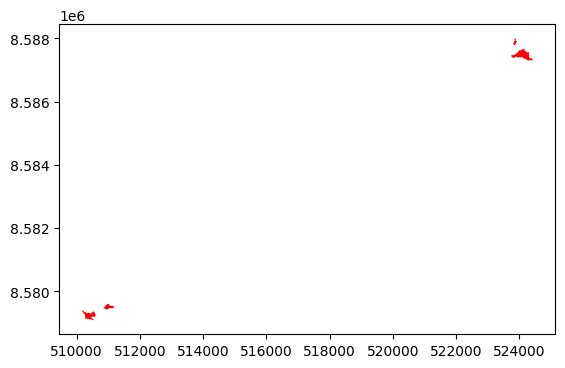

In [123]:
# code_ilot1 = "976100114" # a disparu en 2023 parce que complètement nettoyé donc ok 
code_ilot1 = "976160106"
# code_ilot1 = "976080222"
code1 = "976160119"
code2 = "976110322"
code3 = "976110336"
code5 = "976160107"

ilots1 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code_ilot1]
ilots2 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code1]
ilots3 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code2]
ilots4 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code3]
ilots5 = ilotsMayotte.loc[ilotsMayotte.ident_ilot == code5]


# Create a figure and axes object
fig, ax = plt.subplots()

# Plot the second GeoDataFrame in green
ilots1.plot(ax=ax, color='red', alpha=1)

# Plot the second GeoDataFrame in green
ilots2.plot(ax=ax, color='red', alpha=1)
# Plot the second GeoDataFrame in green
ilots3.plot(ax=ax, color='red', alpha=1)
# Plot the second GeoDataFrame in green
ilots4.plot(ax=ax, color='red', alpha=1)
# Plot the second GeoDataFrame in green
ilots5.plot(ax=ax, color='red', alpha=1)

# Plot the second GeoDataFrame in green
#ilotsMayotte.plot(ax=ax, color='green', alpha=0.1)

# Show the plot
plt.show()

In [106]:
aireParIlot23.loc[976100114] = 0

In [107]:
aireParIlot20.index = aireParIlot20.index.astype(int)
aireParIlot20 = aireParIlot20.sort_index()

aireParIlot23.index = aireParIlot23.index.astype(int)
aireParIlot23 = aireParIlot23.sort_index()

In [108]:
aireParIlot23 = aireParIlot23.astype(float)
diff_aire = aireParIlot23 - aireParIlot20
diff_aire

ident_ilot
976010101    1286.75
976010102    3758.75
976010103    7731.75
976010104     856.00
976010105   -6597.00
              ...   
976170406   -9059.25
976170407     138.00
976170408    3955.25
976170409    1989.50
976170410     609.25
Name: area_1, Length: 811, dtype: float64

In [126]:
diff_aire_trie = diff_aire.sort_values(ascending=False)
print(diff_aire_trie.head(20))

ident_ilot
976160106    101489.75
976160119     61813.00
976110322     52236.00
976110336     50629.00
976160107     49292.00
976160105     47647.25
976160125     47598.75
976160118     46278.75
976160121     46122.00
976100524     42191.25
976160108     39674.25
976160120     37872.25
976100501     36630.00
976160114     35570.25
976160103     34868.00
976160101     34396.50
976100530     32994.50
976120201     29365.75
976070401     26302.00
976110240     25913.25
Name: area_1, dtype: float64


Pas trop de moyens de vérifier pour l'instant, mais ça semble à peu près pas trop mal.

## Pareil pour 2023

In [ ]:
for i in range(len(ilots)):
    ilot = ilots.iloc[i]
    
    polygones_intersectes = pred_2023[pred_2023.intersects(ilot.geometry)]

    if polygones_intersectes.empty:
        continue
    
    polygones_decoupes = polygones_intersectes.intersection(ilot.geometry)
    nouvelle_table = gpd.GeoDataFrame(pd.concat([nouvelle_table, polygones_decoupes], ignore_index=True))
    aire_construite = polygones_decoupes.area.sum()

    ilotsaire.loc[i, 'aire_construite2023'] = aire_construite

    
#ilotsaire = ilotsaire.dropna(subset=['aire_construite2023'])


In [ ]:
#print(ilotsaire.aire_construite2023)

print(valeurs_extremes(ilotsaire, 15, 'aire_construite2023', 'top'))

## On se penche sur les différences

In [ ]:
# Supprimer les lignes où les valeurs de aire_construite2020 et aire_construite2023 sont égales
ilotsairetest = ilotsaire
ilotsairetest = ilotsairetest.drop_duplicates(subset=['aire_construite2020', 'aire_construite2023'], keep=False)


In [ ]:
print(ilotsairetest)

In [ ]:
# Créer une nouvelle colonne contenant la différence entre les valeurs de aire_construite2020 et aire_construite2023
ilotsairetest['difference_aire_construite'] = ilotsairetest['aire_construite2020'] - ilotsairetest['aire_construite2023']
print(ilotsairetest)

In [ ]:
print(valeurs_extremes(ilotsairetest, 50, 'difference_aire_construite', 'top'))

In [ ]:
print(ilots)